# V1.1 — Operator composition order-independence & cascade determinism

**Tier 1 / Verification Protocol §V1.1.** Targets architecture **Decision #12** — the
*contributions-vs-transitions* split that makes operator composition simultaneously **free**
and **deterministic**. Depends on **V0.3** (the conserved-bus runtime) and ties to **V0.5**
(reduction-order determinism).

> Folder note: `verification_notebooks/phaseN` = **Tier N** notebooks. This is Tier 1, *not*
> architecture "Phase 1" (the coupling operator).

### Claims (falsifiable)
1. **Contribution order-independence (theorem-check).** Additive contributions staged into
   conserved buses yield the *same committed state* regardless of operator evaluation order —
   "phenomena emerge by free composition." Any order-dependence beyond floating-point
   reduction noise is a bug (a contribution is secretly stateful → **REDESIGN**).
2. **Cascade determinism (empirical).** When several **transitions** compete to set the *same*
   variable on the *same* cell, the committed value is **ambiguous (order-dependent) without** a
   declared cascade priority, and **deterministic with** it. Demonstrated on the contested
   *drying / pyrolysis / smoldering* case, in two variants (a categorical `phase`, and a mass
   `fate` selector).

### Oracle (independent ground truth)
A **canonical fixed-order run** is the reference (protocol §V1.1): every randomized ordering is
measured against it. For the transition cascade, the reference is the *highest-priority firing*
target per cell (computed independently of evaluation order).

### Tie to V0.5
Contribution staging *is* the conserved-bus **REDUCE** step. Float addition is non-associative,
so permuting the staging order produces ~1e-14 noise — exactly the V0.5 hazard. We show this noise
is below tolerance, **and** that the V0.5 fixes (fixed-order / integer-exact reduction) drive it to
**exactly 0 bitwise**.

### Pre-registered pass criteria (frozen before running)
| # | Metric | Threshold | Failure → outcome |
|---|---|---|---|
| A | max committed-state divergence over **all 120** contribution orderings | **< `SOLVER_TOL`**; and **= 0 bitwise** under fixed/integer-exact reduction | **REDESIGN** (stateful contribution) |
| B1 | transition outcome **without** cascade (negative control) | divergence **> 0** (≥2 distinct outcomes across orderings) — proves necessity | — |
| B2 | transition outcome **with** cascade, both variants | divergence **0** (exactly 1 distinct outcome across all orderings) **and** equals the highest-priority-firing reference | **REDESIGN** the cascade resolver |


In [1]:
"""(1) Setup — imports, frozen pre-registered constants."""
import sys, pathlib, itertools
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import fire_operators as fo
import bus_runtime as br
import determinism as det
import transitions as tr

np.set_printoptions(precision=4, suppress=True)

# ---- PRE-REGISTERED constants (frozen) ----
SOLVER_TOL = 1e-9      # criteria A & B2: divergence must fall below this
SEED       = 0
N_FIRE     = 16        # 3-D fire grid (reuses the V0.3 convention)
DT         = 1.0e-3    # production timestep
N_WARM     = 40        # steps to evolve a realistic, heterogeneous mid-burn state
SCALE_Q    = 1e9       # quantization scale for the integer-exact reduction (V0.5 path)
N_PHASE    = 16        # transition-scenario grid
P          = fo.FireParams()

CONTRIB_OPS = list(fo.CONTRIBUTION_OPS)          # the 5 additive operators
CANON       = list(CONTRIB_OPS)                  # canonical (fixed-order) reference
N_PERM      = len(list(itertools.permutations(CONTRIB_OPS)))
print(f"contribution operators ({len(CONTRIB_OPS)}): {CONTRIB_OPS}")
print(f"permutations to sweep: {N_PERM} (=5!)   SOLVER_TOL={SOLVER_TOL:.0e}")


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0
contribution operators (5): ['pyrolysis', 'combustion', 'conduction', 'o2_supply', 'charge_dissipation']
permutations to sweep: 120 (=5!)   SOLVER_TOL=1e-09


## (2) A representative mid-burn state

Order-independence is only a meaningful test on a *heterogeneous* state where several operators
contribute to the same field on the same cell. We evolve a burn from ignition for `N_WARM` steps to
get realistic gradients, then freeze that state `S` — every order test runs one split step *from
`S`*.

In [2]:
"""(2) Evolve to a heterogeneous mid-burn state S (the fixed test point)."""
c = slice(N_FIRE // 2 - 2, N_FIRE // 2 + 2)
S = br.make_state(N_FIRE, T0=500.0, gas0=0.05, o2=0.23)
S["T"][c, c, c] = 760.0                       # ignition
for _ in range(N_WARM):
    S, _, _, _ = br.step_split(S, P, DT)

# how many operators contribute to each field at S (>=2 ⇒ reduction order matters)
deltas_of = {op: fo.CONTRIBUTION_OPS[op](S, P)[0] for op in CONTRIB_OPS}
contributors = {f: [op for op in CONTRIB_OPS if f in deltas_of[op]] for f in br.FIELDS}
print("field : #contributing operators (>=2 ⇒ float reduction order matters)")
for f in br.FIELDS:
    print(f"   {f:4s}: {len(contributors[f])}  {contributors[f]}")
print(f"\nmid-burn T range: [{S['T'].min():.1f}, {S['T'].max():.1f}] K   "
      f"gas range: [{S['gas'].min():.3f}, {S['gas'].max():.3f}]")


field : #contributing operators (>=2 ⇒ float reduction order matters)
   T   : 3  ['pyrolysis', 'combustion', 'conduction']
   m_s : 1  ['pyrolysis']
   gas : 2  ['pyrolysis', 'combustion']
   char: 1  ['pyrolysis']
   o2  : 2  ['combustion', 'o2_supply']
   q   : 1  ['charge_dissipation']

mid-burn T range: [499.5, 762.2] K   gas range: [0.051, 0.384]


## (3) Part A — contribution order-independence (theorem-check)

**End-to-end:** run the full split step from `S` under all 120 operator orderings; compare each
committed state to the canonical-order reference. The only order-sensitive operation is the
additive `staged[f] += d` reduction, so any divergence is pure floating-point reduction noise.

In [3]:
"""(3a) End-to-end: 120 orderings vs the canonical fixed-order reference."""
base, _, _, _ = br.step_split(S, P, DT, op_order=CANON)
max_div = 0.0
per_perm = []
for order in itertools.permutations(CONTRIB_OPS):
    alt, _, _, _ = br.step_split(S, P, DT, op_order=order)
    d = max(float(np.abs(alt[f] - base[f]).max()) for f in br.FIELDS)
    per_perm.append(d)
    max_div = max(max_div, d)
per_perm = np.array(per_perm)
A_FLOAT_PASS = max_div < SOLVER_TOL
print(f"committed-state divergence over {N_PERM} orderings:")
print(f"   max = {max_div:.2e}   median = {np.median(per_perm):.2e}   "
      f"(SOLVER_TOL = {SOLVER_TOL:.0e})")
print(f"   => order-independent to tolerance: {A_FLOAT_PASS}")


committed-state divergence over 120 orderings:
   max = 0.00e+00   median = 0.00e+00   (SOLVER_TOL = 1e-09)
   => order-independent to tolerance: True


### (3b) V0.5 tie-in — the reduction noise is removable, exactly

The ~1e-14 spread above is the V0.5 reduction-order hazard living inside the staging sum. We reduce
the **same** per-operator contributions three ways across all 120 orderings:

- **naive float** (`+=` in the requested order) — order-sensitive at ~ machine ε;
- **fixed-order float** (canonical operator order, à la V0.5) — bit-identical for every ordering;
- **integer-exact** (quantize → int64, exactly associative) — bit-identical for every ordering.

This isolates the claim: contribution order-independence is *real* (exact under a deterministic
reduction), not merely approximate.

In [4]:
"""(3b) Reduce the staged contributions 3 ways over all orderings; check bit-exactness."""
def reduce_field(field, op_order, mode):
    ops = [op for op in op_order if op in contributors[field]]
    if mode == "int":
        acc = np.zeros(S[field].shape, dtype=np.int64)
        for op in ops:
            acc += np.rint(deltas_of[op][field] * SCALE_Q).astype(np.int64)
        return acc                                   # compare integers exactly
    acc = np.zeros(S[field].shape, dtype=np.float64)
    for op in ops:
        acc = acc + deltas_of[op][field]
    return acc

# overflow guard for the integer path
maxabs = max(float(np.abs(deltas_of[op][f]).max())
             for f in br.FIELDS for op in contributors[f] if len(contributors[f]) >= 1)
assert maxabs * SCALE_Q * len(CONTRIB_OPS) < 9e18, "int64 overflow — lower SCALE_Q"

multi = [f for f in br.FIELDS if len(contributors[f]) >= 2]    # only these can disagree
orders = list(itertools.permutations(CONTRIB_OPS))
report = {}
for f in multi:
    naive  = [reduce_field(f, o, "float") for o in orders]
    fixedo = [reduce_field(f, sorted(contributors[f]), "float") for _ in orders]
    inte   = [reduce_field(f, o, "int") for o in orders]
    # count distinct IEEE-754 bit patterns via the V0.5 helper (det.bitwise_equal)
    def n_patterns(arrs):
        reps = []
        for a in arrs:
            if not any(det.bitwise_equal(a, r) for r in reps):
                reps.append(a)
        return len(reps)
    n_naive = n_patterns(naive)
    n_fixed = sum(1 for k in range(len(fixedo))                       # all == fixedo[0]?
                  if not det.bitwise_equal(fixedo[k], fixedo[0])) == 0
    n_fixed = 1 if n_fixed else 2
    n_int   = len({a.tobytes() for a in inte})                        # exact int compare
    naive_spread = max(float(np.abs(a - naive[0]).max()) for a in naive)
    # the two V0.5 deterministic strategies must also AGREE (fixed float ≈ int/scale)
    int_vs_fixed = det.rel_diff(fixedo[0], inte[0] / SCALE_Q)
    report[f] = dict(n_naive=n_naive, n_fixed=n_fixed, n_int=n_int,
                     spread=naive_spread, int_vs_fixed=int_vs_fixed)

print(f"{'field':5s} {'naive bit-patterns':>19} {'fixed':>7} {'int-exact':>10} "
      f"{'naive spread':>14} {'int≈fixed':>11}")
for f, r in report.items():
    print(f"{f:5s} {r['n_naive']:>19} {r['n_fixed']:>7} {r['n_int']:>10} "
          f"{r['spread']:>14.2e} {r['int_vs_fixed']:>11.2e}")

A_FIXED_EXACT = all(r["n_fixed"] == 1 for r in report.values())
A_INT_EXACT   = all(r["n_int"] == 1 for r in report.values())
hazard_shown  = any(r["n_naive"] > 1 for r in report.values())
print(f"\nfixed-order bit-identical across all orderings: {A_FIXED_EXACT}")
print(f"integer-exact bit-identical across all orderings: {A_INT_EXACT}")
print(f"(naive float shows the V0.5 reduction-order hazard: {hazard_shown})")
A_PASS = A_FLOAT_PASS and A_FIXED_EXACT and A_INT_EXACT
print(f"\n   => PART A PASS: {A_PASS}")


field  naive bit-patterns   fixed  int-exact   naive spread   int≈fixed
T                       3       1          1       1.42e-14    7.75e-08
gas                     1       1          1       0.00e+00    3.37e-08
o2                      1       1          1       0.00e+00    1.28e-07

fixed-order bit-identical across all orderings: True
integer-exact bit-identical across all orderings: True
(naive float shows the V0.5 reduction-order hazard: True)

   => PART A PASS: True


## (4) Part B — transition cascade determinism

Transitions *change a variable's value/category*; they do **not** commute. The contested case:
**drying**, **pyrolysis**, and **smoldering** all want to set one variable on the same charring,
still-moist, oxygen-fed cells. We sweep all orderings of the three transitions and compare the
committed map **without** a cascade (last-writer-wins) vs **with** the declared cascade priority
(`smolder > pyrolysis > drying`). The reference is the highest-priority *firing* target per cell.

In [5]:
"""(4a) Variant 1 — categorical phase: ordered (ambiguous) vs cascade (deterministic)."""
p_tr = tr.TransitionParams()
state_tr, phase0, fate0 = tr.make_scenario(N=N_PHASE, seed=SEED)
props = tr.phase_proposals(state_tr, p_tr)
names = [pr["name"] for pr in props]
by_name = {pr["name"]: pr for pr in props}
orders3 = list(itertools.permutations(names))
contested = tr.contested_mask(props)
print(f"contested cells (>=2 transitions fire): {int(contested.sum())} of {phase0.size}")
for pr in props:
    print(f"   {pr['name']:10s} fires {int(pr['mask'].sum()):5d} cells  "
          f"target={tr.PHASE_NAMES[pr['target']]:11s} priority={pr['priority']}")

def reference_winner(field0, proposals):
    out = np.array(field0, copy=True)
    best = np.full(out.shape, -2**31, dtype=np.int64)
    for pr in sorted(proposals, key=lambda x: x["priority"]):
        take = pr["mask"] & (pr["priority"] > best)
        out[take] = pr["target"]; best[take] = pr["priority"]
    return out

# WITHOUT cascade: last-writer-wins depends on order
ordered_maps = [tr.apply_transitions_ordered(phase0, props, o) for o in orders3]
distinct_without = len({m.tobytes() for m in ordered_maps})
div_without = max(int(np.count_nonzero(m != ordered_maps[0])) for m in ordered_maps)

# WITH cascade: feed proposals in every list order; result must be invariant
casc_maps = [tr.apply_transitions_cascade(phase0, [by_name[nm] for nm in o]) for o in orders3]
distinct_with = len({m.tobytes() for m in casc_maps})
casc_correct = bool(np.array_equal(casc_maps[0], reference_winner(phase0, props)))
phase_casc = casc_maps[0]

print(f"\nWITHOUT cascade: {distinct_without} distinct phase-maps over {len(orders3)} orderings "
      f"(up to {div_without} cells disagree)  ⇒ order-dependent")
print(f"WITH cascade:    {distinct_with} distinct phase-map; equals priority reference: {casc_correct}")
B_PHASE_PASS = (distinct_without > 1) and (distinct_with == 1) and casc_correct
print(f"   => phase variant PASS: {B_PHASE_PASS}")


contested cells (>=2 transitions fire): 360 of 4096
   drying     fires   984 cells  target=DRY         priority=1
   pyrolysis  fires   984 cells  target=PYROLYZING  priority=2
   smolder    fires   216 cells  target=SMOLDERING  priority=3

WITHOUT cascade: 4 distinct phase-maps over 6 orderings (up to 360 cells disagree)  ⇒ order-dependent
WITH cascade:    1 distinct phase-map; equals priority reference: True
   => phase variant PASS: True


In [6]:
"""(4b) Variant 2 — mass `fate` selector: the cascade generalizes; routing applied once."""
fprops = tr.fate_proposals(state_tr, p_tr)
fby = {pr["name"]: pr for pr in fprops}
f_ordered = [tr.apply_transitions_ordered(fate0, fprops, o) for o in orders3]
f_distinct_without = len({m.tobytes() for m in f_ordered})
f_casc = [tr.apply_transitions_cascade(fate0, [fby[nm] for nm in o]) for o in orders3]
f_distinct_with = len({m.tobytes() for m in f_casc})
f_correct = bool(np.array_equal(f_casc[0], reference_winner(fate0, fprops)))
fate_casc = f_casc[0]

# routing is a value-transition applied ONCE on the resolved fate (not a bus contribution)
routed = tr.apply_routing(fate_casc, state_tr["m_s"])
fired = fate_casc != tr.FATE_NONE
mass_in = float(state_tr["m_s"][fired].sum())
mass_out = float(sum(v.sum() for v in routed.values()))
mass_resid = abs(mass_in - mass_out) / (mass_in + 1e-30)

print(f"WITHOUT cascade: {f_distinct_without} distinct fate-maps  ⇒ order-dependent")
print(f"WITH cascade:    {f_distinct_with} distinct fate-map; equals reference: {f_correct}")
print(f"routing mass conservation |in-out|/in = {mass_resid:.2e}  (single deterministic apply)")
B_FATE_PASS = (f_distinct_without > 1) and (f_distinct_with == 1) and f_correct and (mass_resid < 1e-12)
print(f"   => mass-routing variant PASS: {B_FATE_PASS}")
B_PASS = B_PHASE_PASS and B_FATE_PASS


WITHOUT cascade: 4 distinct fate-maps  ⇒ order-dependent
WITH cascade:    1 distinct fate-map; equals reference: True
routing mass conservation |in-out|/in = 0.00e+00  (single deterministic apply)
   => mass-routing variant PASS: True


## (5) Figures

saved figure -> /workspace/nebula/verification_notebooks/phase1/results/V1_1_composition_order.png


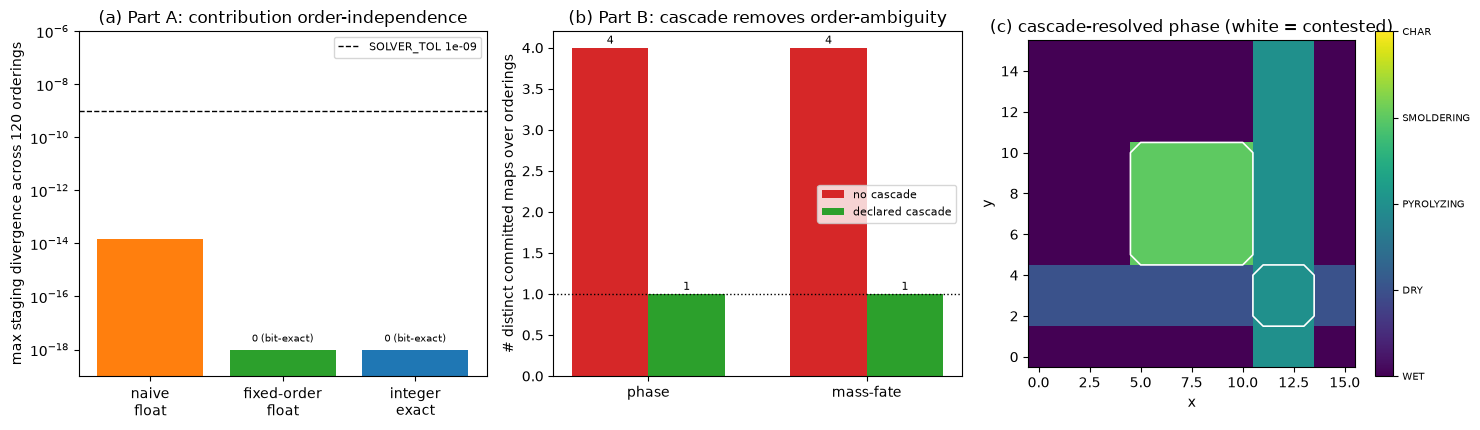

In [7]:
"""(5) Figures: (a) Part A reductions; (b) Part B distinct-outcomes; (c) contested map."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) Part A — max divergence per reduction strategy vs tolerance
strategies = ["naive\nfloat", "fixed-order\nfloat", "integer\nexact"]
naive_spread = max(r["spread"] for r in report.values())
heights = [max(naive_spread, 1e-18), 1e-18, 1e-18]   # exact-0 shown at the ε floor
colors = ["tab:orange", "tab:green", "tab:blue"]
ax[0].bar(strategies, heights, color=colors)
ax[0].axhline(SOLVER_TOL, ls="--", color="k", lw=1, label=f"SOLVER_TOL {SOLVER_TOL:.0e}")
ax[0].set_yscale("log"); ax[0].set_ylim(1e-19, 1e-6)
ax[0].set_ylabel("max staging divergence across 120 orderings")
ax[0].set_title("(a) Part A: contribution order-independence")
ax[0].text(1, 2e-18, "0 (bit-exact)", ha="center", fontsize=7)
ax[0].text(2, 2e-18, "0 (bit-exact)", ha="center", fontsize=7)
ax[0].legend(fontsize=8)

# (b) Part B — distinct committed outcomes, without vs with cascade
labels = ["phase", "mass-fate"]
without = [distinct_without, f_distinct_without]
withc = [distinct_with, f_distinct_with]
x = np.arange(len(labels)); w = 0.35
ax[1].bar(x - w/2, without, w, color="tab:red", label="no cascade")
ax[1].bar(x + w/2, withc, w, color="tab:green", label="declared cascade")
ax[1].axhline(1, ls=":", color="k", lw=1)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("# distinct committed maps over orderings")
ax[1].set_title("(b) Part B: cascade removes order-ambiguity")
ax[1].legend(fontsize=8)
for xi, v in zip(x - w/2, without): ax[1].text(xi, v + 0.05, str(v), ha="center", fontsize=8)
for xi, v in zip(x + w/2, withc): ax[1].text(xi, v + 0.05, str(v), ha="center", fontsize=8)

# (c) contested region — cascade-resolved phase, mid-plane slice, contested outlined
z = N_PHASE // 2
sl = phase_casc[:, :, z]
im = ax[2].imshow(sl, cmap="viridis", vmin=0, vmax=4, origin="lower")
ax[2].contour(contested[:, :, z].astype(float), levels=[0.5], colors="white", linewidths=1.2)
cb = fig.colorbar(im, ax=ax[2], ticks=[0, 1, 2, 3, 4])
cb.ax.set_yticklabels([tr.PHASE_NAMES[i] for i in range(5)], fontsize=7)
ax[2].set_title("(c) cascade-resolved phase (white = contested)")
ax[2].set_xlabel("x"); ax[2].set_ylabel("y")

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase1" / "results"
outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(outdir / "V1_1_composition_order.png", dpi=110)
print(f"saved figure -> {outdir / 'V1_1_composition_order.png'}")
plt.show()


In [8]:
"""(6) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:34s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 78)
print("V1.1 — OPERATOR COMPOSITION ORDER-INDEPENDENCE & CASCADE DETERMINISM — VERDICT")
print("=" * 78)
verdict("A. contribution order-independence", A_PASS,
        f"float divergence max={max_div:.1e} (< {SOLVER_TOL:.0e}); fixed-order & integer-exact "
        f"bit-identical across all {N_PERM} orderings", "REDESIGN (stateful contribution)")
verdict("B1. cascade necessity (no cascade)", (distinct_without > 1 and f_distinct_without > 1),
        f"order-dependent: phase {distinct_without} maps, mass-fate {f_distinct_without} maps "
        f"over orderings", "—")
verdict("B2. cascade determinism", B_PASS,
        f"with cascade: exactly 1 map each; equals priority reference (phase={casc_correct}, "
        f"fate={f_correct}); routing conserves mass", "REDESIGN cascade resolver")

ALL_PASS = A_PASS and B_PASS and (distinct_without > 1) and (f_distinct_without > 1)
print("=" * 78)
print(f"  V1.1 OVERALL: {'PASS — additive contributions compose order-free; declared cascade' if ALL_PASS else 'FAIL — see outcome class above'}")
if ALL_PASS:
    print("                priority makes contested transitions deterministic (Decision #12 holds)")
print("=" * 78)
assert ALL_PASS, "V1.1 did not pass — see verdict above."


V1.1 — OPERATOR COMPOSITION ORDER-INDEPENDENCE & CASCADE DETERMINISM — VERDICT
  [OK ] A. contribution order-independence PASS
        float divergence max=0.0e+00 (< 1e-09); fixed-order & integer-exact bit-identical across all 120 orderings
  [OK ] B1. cascade necessity (no cascade) PASS
        order-dependent: phase 4 maps, mass-fate 4 maps over orderings
  [OK ] B2. cascade determinism            PASS
        with cascade: exactly 1 map each; equals priority reference (phase=True, fate=True); routing conserves mass
  V1.1 OVERALL: PASS — additive contributions compose order-free; declared cascade
                priority makes contested transitions deterministic (Decision #12 holds)
